<a href="https://colab.research.google.com/github/rasyaraditya969/Quant-Research-project-nexus/blob/main/Xero_Nexus_QRM_quant_regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEXUS-QRM — Macro, News & Market Quant Research Engine

**NEXUS-QRM (Quantitative Regime & Market Intelligence)** is a Colab-ready research framework for:
- indices, sectors and commodities
- market momentum, realized volatility and VIX
- macro-regime classification
- sector rotation
- cross-asset correlation / relative strength
- rule-based signal generation and backtesting
- parameter optimization
- walk-forward and out-of-sample testing
- turnover and transaction-cost analysis
- Monte Carlo / bootstrap robustness
- optional news ingestion + sentiment scoring

> This is a research/backtesting framework, not a promise of future trading performance. Historical backtests can suffer from look-ahead bias, survivorship bias, data revisions and execution costs.


**20-day momentum:**



$$
M_t = \frac{P_t}{P_{t-20}} - 1
$$

$$
\begin{aligned}
M_t^{(n)}
&= \frac{P_t}{P_{t-n}}-1
\\[4pt]
Z_t^{(n)}
&= \frac{M_t^{(n)}-\mu_M^{(n)}}{\sigma_M^{(n)}}
\\[4pt]
MVA_t^{(n)}
&= \frac{M_t^{(n)}}{\sigma_t^{(n)}}
\\[4pt]
MM_t
&=
\sum_{n\in\{5,20,60,120,252\}}
w_n Z_t^{(n)}
\\[4pt]
\sum_n w_n &= 1
\\[4pt]
CSM_{i,t}
&=
\frac{P_{i,t}}{P_{i,t-n}}-1
\\[4pt]
Score_{i,t}
&=
2\frac{Rank(CSM_{i,t})-1}{N-1}-1
\\[4pt]
Signal_t
&=
f(MM_t,Score_{i,t})
\end{aligned}
$$

Momentum → Alpha Equation

In [4]:
# =========================
# 0) INSTALL / IMPORTS
# =========================
!pip -q install yfinance feedparser vaderSentiment scipy scikit-learn statsmodels

import warnings, math, time, json, re, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import feedparser

from scipy.stats import spearmanr, zscore
from scipy.optimize import minimize
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

print("NEXUS-QRM initialized.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00
NEXUS-QRM initialized.


## 1. Research universe

The default universe is deliberately broad so the same pipeline can be used for index futures/ETFs and commodities. You can replace the tickers with your broker's preferred symbols.

**Core indices:** S&P 500, Nasdaq-100, Dow Jones, Russell 2000  
**Volatility:** VIX  
**Rates / macro proxies:** 10Y Treasury, 2Y Treasury, Dollar Index  
**Commodities:** Gold, Oil, Silver, Copper  
**Sectors:** XLK, XLF, XLE, XLV, XLI, XLY, XLP, XLB, XLC, XLU, XLRE  


In [5]:
# =========================
# 2) CONFIGURATION
# =========================
START = "2018-01-01"
END = None

TICKERS = {
    "SPX": "^GSPC",
    "NDX": "^NDX",
    "DJI": "^DJI",
    "RUT": "^RUT",
    "VIX": "^VIX",
    "DXY": "DX-Y.NYB",
    "US10Y": "^TNX",
    "US2Y": "^IRX",
    "GOLD": "GC=F",
    "SILVER": "SI=F",
    "OIL": "CL=F",
    "COPPER": "HG=F",
}

SECTORS = {
    "Technology":"XLK", "Financials":"XLF", "Energy":"XLE",
    "HealthCare":"XLV", "Industrials":"XLI", "Discretionary":"XLY",
    "Staples":"XLP", "Materials":"XLB", "Communication":"XLC",
    "Utilities":"XLU", "RealEstate":"XLRE"
}

ALL_TICKERS = list(TICKERS.values()) + list(SECTORS.values())


In [6]:
# =========================
# 3) DOWNLOAD MARKET DATA
# =========================
raw = yf.download(
    ALL_TICKERS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

# yfinance can return MultiIndex columns
if isinstance(raw.columns, pd.MultiIndex):
    close = raw["Close"].copy()
    volume = raw["Volume"].copy()
else:
    close = raw[["Close"]].copy()
    volume = raw[["Volume"]].copy()

# Rename symbols -> human labels where possible
reverse_map = {v:k for k,v in {**TICKERS, **SECTORS}.items()}
close = close.rename(columns=reverse_map)
volume = volume.rename(columns=reverse_map)

close = close.dropna(how="all").sort_index()
close = close.ffill()
returns = close.pct_change().dropna()

print("Data:", close.index.min().date(), "to", close.index.max().date())
print("Assets:", list(close.columns))
close.tail()


Data: 2018-01-02 to 2026-09-25
Assets: ['OIL', 'DXY', 'GOLD', 'COPPER', 'SILVER', 'Materials', 'Communication', 'Energy', 'Financials', 'Industrials', 'Technology', 'Staples', 'RealEstate', 'Utilities', 'HealthCare', 'Discretionary', 'DJI', 'SPX', 'US2Y', 'NDX', 'RUT', 'US10Y', 'VIX']


Ticker,OIL,DXY,GOLD,COPPER,SILVER,Materials,Communication,Energy,Financials,Industrials,...,Utilities,HealthCare,Discretionary,DJI,SPX,US2Y,NDX,RUT,US10Y,VIX
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-21,95.779999,100.430000,4383.899902,6.6865,65.824997,49.709999,114.750000,62.459999,55.900002,169.979996,...,40.660000,169.009995,112.230003,52048.828125,7764.700195,3.982,30482.349609,2875.360107,4.963,14.87
2026-09-22,94.589996,100.599998,4376.399902,6.7595,65.931999,50.529999,113.529999,61.779999,54.799999,170.270004,...,40.529999,169.889999,112.330002,51863.691406,7764.640137,4.005,30732.400391,2889.919922,4.968,14.21
2026-09-23,92.160004,101.099998,4318.399902,6.6780,64.382004,50.279999,112.559998,62.369999,54.540001,170.100006,...,39.750000,168.800003,110.650002,51511.589844,7706.029785,4.028,30470.289062,2838.659912,5.114,15.18
2026-09-24,94.610001,101.290001,4298.000000,6.7185,63.457001,49.680000,113.989998,62.599998,54.529999,168.830002,...,39.360001,169.869995,110.320000,51349.980469,7704.129883,4.068,30478.859375,2835.570068,5.162,15.67
2026-09-25,92.410004,100.970001,4321.200195,6.6955,64.245003,49.799999,112.959999,62.040001,54.840000,170.429993,...,39.509998,170.699997,110.559998,51828.621094,7743.410156,4.070,30608.130859,2837.550049,5.184,14.87


## 4. Feature engineering

The feature layer reproduces the type of diagnostics shown in your screenshot:
- market momentum
- 20-day realized volatility
- VIX
- economic/regime state
- trend and relative-strength features
- cross-asset relationships

The features are calculated only from information available up to each timestamp.


In [7]:
# =========================
# 4) FEATURE ENGINEERING
# =========================
def momentum(s, n=20):
    return s.pct_change(n)

def realized_vol(s, n=20, annualize=True):
    v = s.pct_change().rolling(n).std()
    return v * np.sqrt(252) if annualize else v

def rolling_z(s, n=60):
    mu = s.rolling(n).mean()
    sd = s.rolling(n).std()
    return (s - mu) / sd.replace(0, np.nan)

features = pd.DataFrame(index=close.index)

features["SPX_Momentum_20D"] = momentum(close["SPX"], 20)
features["NDX_Momentum_20D"] = momentum(close["NDX"], 20)
features["SPX_Vol_20D"] = realized_vol(close["SPX"], 20)
features["NDX_Vol_20D"] = realized_vol(close["NDX"], 20)
features["VIX"] = close["VIX"]
features["VIX_Z60"] = rolling_z(close["VIX"], 60)

# Cross-asset signals
features["DXY_Momentum_20D"] = momentum(close["DXY"], 20)
features["GOLD_Momentum_20D"] = momentum(close["GOLD"], 20)
features["OIL_Momentum_20D"] = momentum(close["OIL"], 20)
features["COPPER_Momentum_20D"] = momentum(close["COPPER"], 20)

# Breadth proxy: % of sector ETFs above their 50-day mean
sector_close = close[list(SECTORS.keys())]
sector_ma50 = sector_close.rolling(50).mean()
features["Sector_Breadth"] = (sector_close > sector_ma50).mean(axis=1)

# Simple regime score
features["Growth_Score"] = (
    rolling_z(features["SPX_Momentum_20D"], 60)
    - rolling_z(features["DXY_Momentum_20D"], 60)
    - rolling_z(features["SPX_Vol_20D"], 60)
    + rolling_z(features["Sector_Breadth"], 60)
)

features["Regime"] = np.select(
    [
        features["Growth_Score"] > 0.75,
        features["Growth_Score"] < -0.75
    ],
    ["Expansion/Risk-On", "Contraction/Risk-Off"],
    default="Transition"
)

features.tail()


,SPX_Momentum_20D,NDX_Momentum_20D,SPX_Vol_20D,NDX_Vol_20D,VIX,VIX_Z60,DXY_Momentum_20D,GOLD_Momentum_20D,OIL_Momentum_20D,COPPER_Momentum_20D,Sector_Breadth,Growth_Score,Regime
Date,,,,,,,,,,,,,
2026-09-21,0.014614,0.050276,0.106202,0.160621,14.87,-0.952393,0.014444,-0.066818,0.126691,0.013260,0.363636,-2.281779,Contraction/Risk-Off
2026-09-22,0.011379,0.052147,0.105832,0.161324,14.21,-1.386748,0.016983,-0.067760,0.148494,0.007452,0.363636,-2.647343,Contraction/Risk-Off
2026-09-23,0.003951,0.042628,0.109700,0.165997,15.18,-0.660175,0.019462,-0.071970,0.120759,0.012662,0.363636,-3.377294,Contraction/Risk-Off
2026-09-24,-0.003474,0.028247,0.106553,0.159749,15.67,-0.292146,0.021480,-0.078473,0.132647,0.019964,0.363636,-3.799207,Contraction/Risk-Off
2026-09-25,0.004104,0.039910,0.107744,0.156811,14.87,-0.854276,0.012738,-0.046072,0.108034,0.020344,0.363636,-2.727060,Contraction/Risk-Off


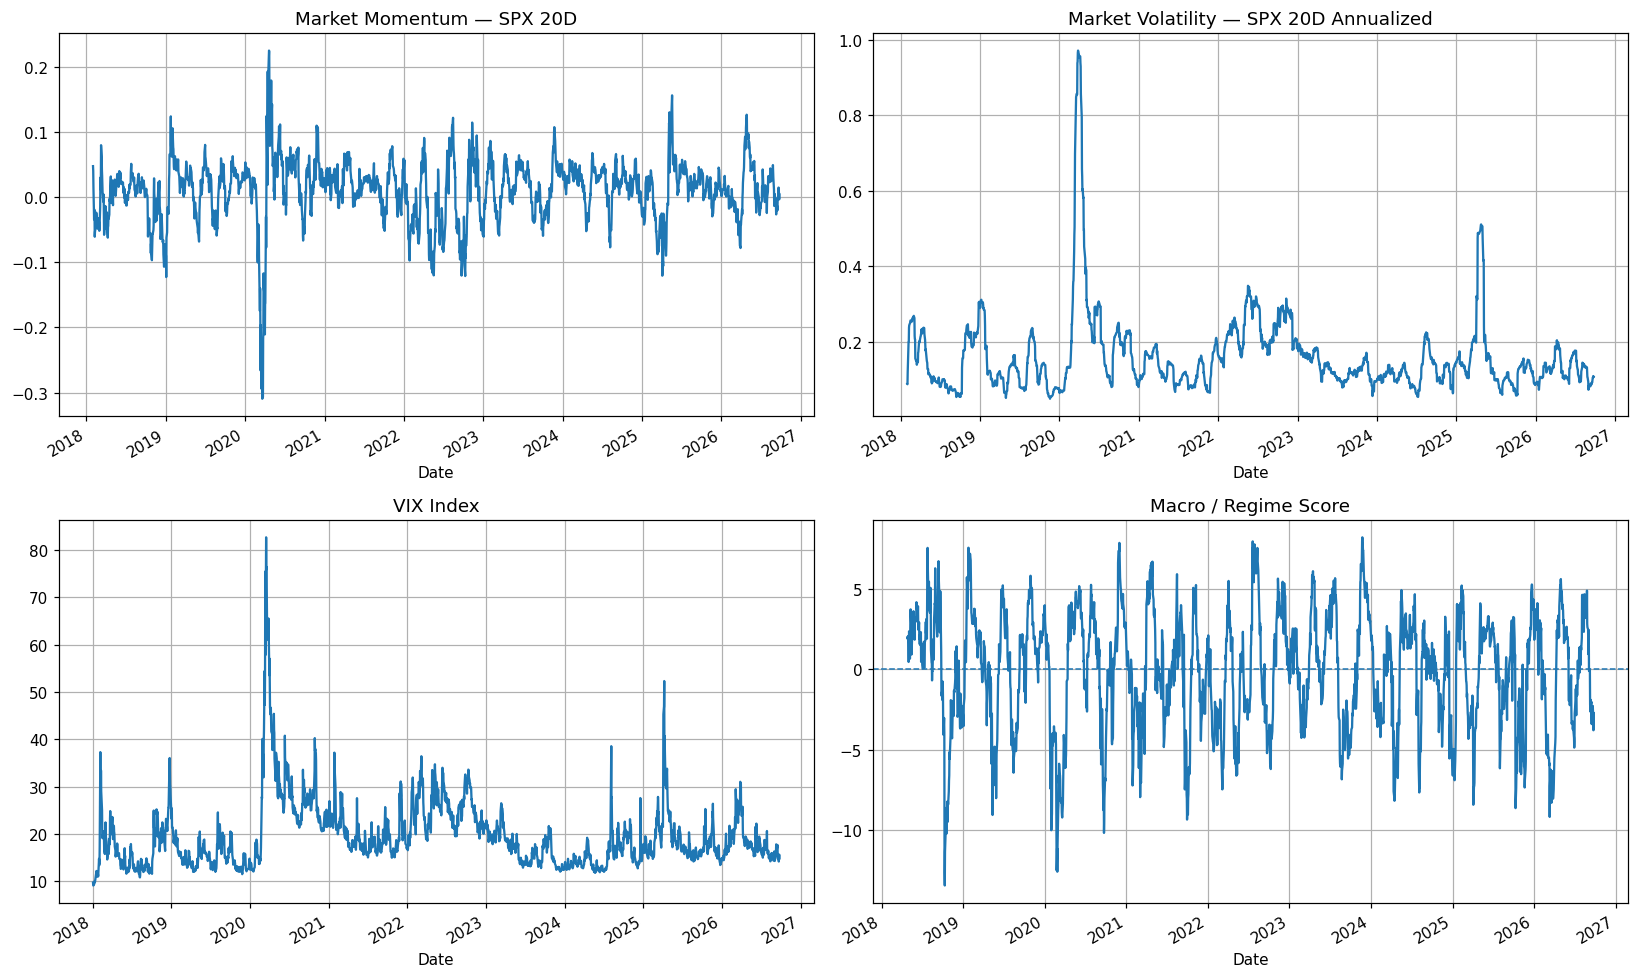

In [8]:
# =========================
# 5) VISUAL DIAGNOSTICS
# =========================
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

features["SPX_Momentum_20D"].plot(ax=axes[0,0], title="Market Momentum — SPX 20D")
features["SPX_Vol_20D"].plot(ax=axes[0,1], title="Market Volatility — SPX 20D Annualized")
features["VIX"].plot(ax=axes[1,0], title="VIX Index")
features["Growth_Score"].plot(ax=axes[1,1], title="Macro / Regime Score")
axes[1,1].axhline(0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()


## 6. Sector rotation

The sector table ranks sectors by momentum and risk-adjusted momentum. It is intended as a research screen, not a recommendation.


In [9]:
# =========================
# 6) SECTOR ROTATION
# =========================
sector_mom = pd.DataFrame({
    "1M": sector_close.pct_change(21).iloc[-1],
    "3M": sector_close.pct_change(63).iloc[-1],
    "6M": sector_close.pct_change(126).iloc[-1],
    "Vol20": sector_close.pct_change().rolling(20).std().iloc[-1] * np.sqrt(252),
})
sector_mom["RiskAdj_1M"] = sector_mom["1M"] / sector_mom["Vol20"].replace(0, np.nan)
sector_mom["Composite"] = (
    0.45*sector_mom["1M"] +
    0.35*sector_mom["3M"] +
    0.20*sector_mom["6M"]
)
sector_mom.sort_values("Composite", ascending=False)


,1M,3M,6M,Vol20,RiskAdj_1M,Composite
Ticker,,,,,,
Technology,0.041827,0.059808,0.543007,0.184927,0.226183,0.148357
HealthCare,-0.001321,0.066028,0.196697,0.133684,-0.009884,0.061855
Energy,0.001907,0.164777,0.014507,0.207504,0.009189,0.061431
Communication,0.017254,0.050540,0.052493,0.219205,0.078712,0.035952
Financials,-0.049169,0.024462,0.141995,0.134350,-0.365977,0.014834
Staples,-0.029153,-0.020983,0.015789,0.103077,-0.282825,-0.017305
Industrials,-0.044250,-0.064959,0.093854,0.127390,-0.347361,-0.023878
Materials,-0.060132,-0.012452,0.022942,0.145620,-0.412936,-0.026829
Discretionary,-0.043808,-0.053932,0.050769,0.153425,-0.285535,-0.028436


## 7. Cross-asset correlation matrix

This is useful for checking whether an index move is occurring together with or against rates, USD, gold, oil and other risk proxies.


In [10]:
# =========================
# 7) CORRELATION MATRIX
# =========================
corr_assets = ["SPX","NDX","DJI","RUT","DXY","US10Y","GOLD","SILVER","OIL","COPPER"]
corr = returns[corr_assets].rolling(60).corr().loc[returns.index[-1]]
print("Latest 60D rolling correlation:")
display(corr.round(2))


Latest 60D rolling correlation:


Ticker,SPX,NDX,DJI,RUT,DXY,US10Y,GOLD,SILVER,OIL,COPPER
Ticker,,,,,,,,,,
SPX,1.00,0.90,0.86,0.80,-0.32,-0.43,0.41,0.41,-0.59,0.53
NDX,0.90,1.00,0.61,0.76,-0.29,-0.31,0.39,0.48,-0.49,0.58
DJI,0.86,0.61,1.00,0.72,-0.27,-0.45,0.39,0.30,-0.62,0.40
RUT,0.80,0.76,0.72,1.00,-0.34,-0.55,0.44,0.44,-0.51,0.52
DXY,-0.32,-0.29,-0.27,-0.34,1.00,0.33,-0.52,-0.39,0.02,-0.25
US10Y,-0.43,-0.31,-0.45,-0.55,0.33,1.00,-0.31,-0.33,0.48,-0.32
GOLD,0.41,0.39,0.39,0.44,-0.52,-0.31,1.00,0.84,-0.24,0.44
SILVER,0.41,0.48,0.30,0.44,-0.39,-0.33,0.84,1.00,-0.25,0.61
OIL,-0.59,-0.49,-0.62,-0.51,0.02,0.48,-0.24,-0.25,1.00,-0.40


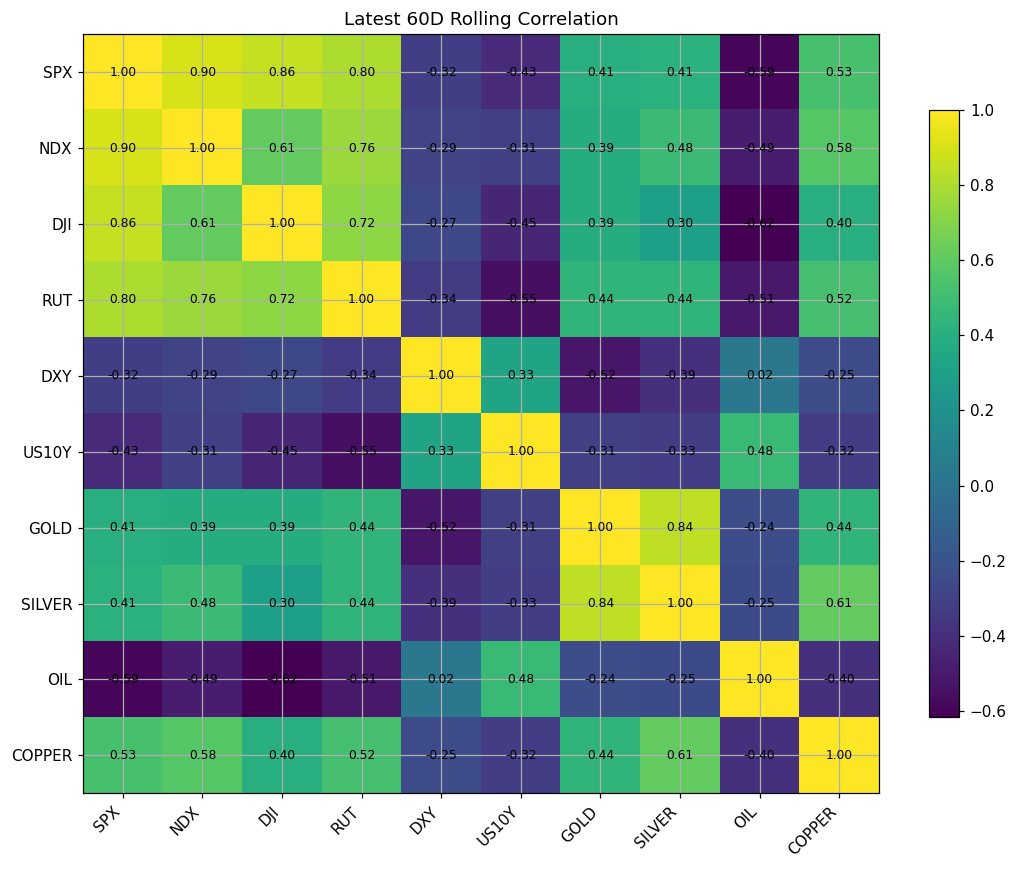

In [11]:
# Heatmap without seaborn
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Latest 60D Rolling Correlation")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## 8. A transparent regime-based trading model

The example strategy trades SPX using a combination of:
1. 20-day momentum
2. volatility filter
3. macro regime score

It is intentionally simple and auditable. Replace it with your own alpha model later.


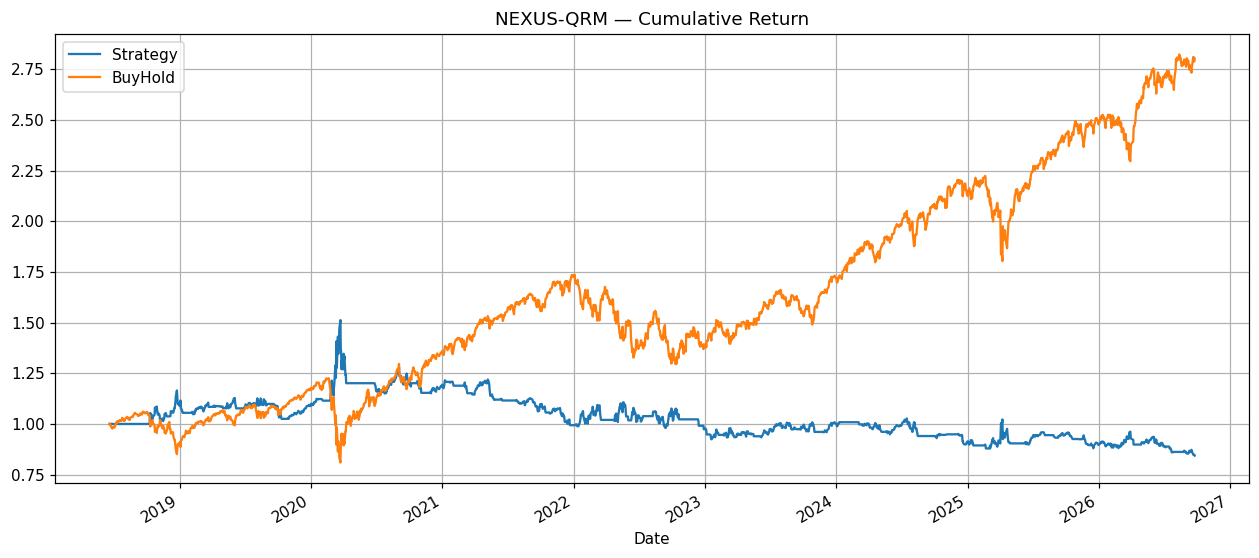

In [12]:
# =========================
# 8) SIGNAL ENGINE
# =========================
def make_signal(df):
    sig = pd.Series(0.0, index=df.index)
    long_cond = (
        (df["SPX_Momentum_20D"] > 0) &
        (df["Growth_Score"] > 0) &
        (df["SPX_Vol_20D"] < df["SPX_Vol_20D"].rolling(252).median())
    )
    short_cond = (
        (df["SPX_Momentum_20D"] < 0) &
        (df["Growth_Score"] < 0)
    )
    sig[long_cond] = 1
    sig[short_cond] = -1
    return sig

features["Signal"] = make_signal(features)
# Shift one day to prevent using today's close to trade today's close.
features["Position"] = features["Signal"].shift(1).fillna(0)

strategy_ret = features["Position"] * returns["SPX"]
strategy_ret = strategy_ret.dropna()

equity = (1 + strategy_ret).cumprod()
benchmark = (1 + returns["SPX"].reindex(strategy_ret.index).fillna(0)).cumprod()

pd.DataFrame({"Strategy":equity, "BuyHold":benchmark}).plot(
    figsize=(14,6), title="NEXUS-QRM — Cumulative Return"
)
plt.show()


In [13]:
# =========================
# 9) PERFORMANCE METRICS
# =========================
def performance_metrics(r, periods=252):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return {}
    eq = (1+r).cumprod()
    years = len(r)/periods
    total_return = eq.iloc[-1]-1
    cagr = eq.iloc[-1]**(1/years)-1 if years > 0 else np.nan
    ann_vol = r.std()*np.sqrt(periods)
    sharpe = (r.mean()/r.std())*np.sqrt(periods) if r.std() else np.nan
    downside = r[r<0].std()*np.sqrt(periods)
    sortino = (r.mean()*periods)/downside if downside else np.nan
    dd = eq/eq.cummax()-1
    max_dd = dd.min()
    calmar = cagr/abs(max_dd) if max_dd != 0 else np.nan
    turnover = strategy_turnover(features["Position"]).mean()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Avg Daily Turnover": turnover,
        "Observations": len(r)
    }

def strategy_turnover(position):
    return position.diff().abs().fillna(0)

metrics = pd.Series(performance_metrics(strategy_ret))
display(metrics.to_frame("Value"))


,Value
Total Return,-0.156033
CAGR,-0.020304
Annualized Vol,0.164046
Sharpe,-0.042991
Sortino,-0.041951
Max Drawdown,-0.441994
Calmar,-0.045938
Avg Daily Turnover,0.131304
Observations,2084.000000


## 10. Turnover and transaction-cost analysis

Turnover is estimated from changes in target position. The cost model is deliberately explicit so you can replace it with your broker/futures assumptions.


In [14]:
# =========================
# 10) TRANSACTION COSTS
# =========================
COST_BPS_PER_UNIT_TURNOVER = 2.0  # example research assumption

turnover = strategy_turnover(features["Position"]).reindex(strategy_ret.index).fillna(0)
cost = turnover * (COST_BPS_PER_UNIT_TURNOVER / 10000)
net_ret = strategy_ret - cost

cost_metrics = pd.Series(performance_metrics(net_ret))
display(pd.DataFrame({
    "Gross": pd.Series(performance_metrics(strategy_ret)),
    "Net": cost_metrics
}))


,Gross,Net
Total Return,-0.156033,-0.203435
CAGR,-0.020304,-0.027128
Annualized Vol,0.164046,0.164045
Sharpe,-0.042991,-0.085597
Sortino,-0.041951,-0.087369
Max Drawdown,-0.441994,-0.468791
Calmar,-0.045938,-0.057869
Avg Daily Turnover,0.131304,0.131304
Observations,2084.000000,2084.000000


## 11. Parameter optimization

Grid-search momentum and volatility lookback values **inside a training sample**. Do not select parameters using the final test period.


In [15]:
# =========================
# 11) PARAMETER OPTIMIZATION
# =========================
def backtest_params(close_spx, growth_score, mom_n=20, vol_n=20,
                    vol_filter=True):
    mom = close_spx.pct_change(mom_n)
    vol = close_spx.pct_change().rolling(vol_n).std()*np.sqrt(252)

    s = pd.Series(0.0, index=close_spx.index)
    s[(mom > 0) & (growth_score > 0)] = 1
    s[(mom < 0) & (growth_score < 0)] = -1

    if vol_filter:
        median_vol = vol.rolling(252).median()
        s[(s == 1) & (vol >= median_vol)] = 0

    pos = s.shift(1).fillna(0)
    r = pos * close_spx.pct_change()
    return r.dropna()

param_rows = []
train_end = int(len(close)*0.70)

train_idx = close.index[:train_end]
for mom_n in [5,10,20,30,60]:
    for vol_n in [10,20,30,60]:
        r = backtest_params(
            close["SPX"].loc[train_idx],
            features["Growth_Score"].loc[train_idx],
            mom_n, vol_n
        )
        m = performance_metrics(r)
        param_rows.append({
            "mom_n":mom_n, "vol_n":vol_n,
            "Sharpe":m.get("Sharpe", np.nan),
            "CAGR":m.get("CAGR", np.nan),
            "MaxDD":m.get("Max Drawdown", np.nan)
        })

opt = pd.DataFrame(param_rows).sort_values(
    ["Sharpe","CAGR"], ascending=False
).reset_index(drop=True)

display(opt.head(10))


,mom_n,vol_n,Sharpe,CAGR,MaxDD
0,60,60,0.289022,0.034035,-0.273512
1,10,10,0.288616,0.035110,-0.292888
2,60,10,0.282387,0.033595,-0.246683
3,10,60,0.266098,0.030772,-0.361445
4,10,20,0.229603,0.024641,-0.323937
5,20,10,0.229127,0.025128,-0.314358
6,20,60,0.221135,0.023478,-0.383677
7,60,30,0.220957,0.022930,-0.265268
8,10,30,0.204566,0.020430,-0.356147
9,60,20,0.204034,0.020169,-0.269265


## 12. Walk-forward testing

Walk-forward testing repeatedly:
- trains/optimizes on a past window
- selects parameters
- evaluates only on the following unseen window
- rolls forward

This is closer to how a live research process behaves than a single in-sample backtest.


In [16]:
# =========================
# 12) WALK-FORWARD TEST
# =========================
def walk_forward(close_spx, growth_score,
                 train_days=756, test_days=126):
    all_oos = []
    selected = []

    start = train_days
    while start < len(close_spx):
        train_slice = slice(start-train_days, start)
        test_slice = slice(start, min(start+test_days, len(close_spx)))

        train_prices = close_spx.iloc[train_slice]
        train_growth = growth_score.iloc[train_slice]

        rows = []
        for mom_n in [5,10,20,30,60]:
            for vol_n in [10,20,30,60]:
                r = backtest_params(train_prices, train_growth, mom_n, vol_n)
                m = performance_metrics(r)
                rows.append((m.get("Sharpe",-999), mom_n, vol_n))

        best = sorted(rows, reverse=True)[0]
        _, best_mom, best_vol = best

        # Recompute signal using the selected parameters across the
        # train + test boundary, then keep only the test segment.
        combined_prices = close_spx.iloc[start-train_days:min(start+test_days, len(close_spx))]
        combined_growth = growth_score.iloc[start-train_days:min(start+test_days, len(close_spx))]
        rr = backtest_params(combined_prices, combined_growth, best_mom, best_vol)

        test_index = close_spx.index[test_slice]
        oos = rr.reindex(test_index).dropna()
        all_oos.append(oos)

        selected.append({
            "test_start": test_index[0] if len(test_index) else None,
            "test_end": test_index[-1] if len(test_index) else None,
            "mom_n": best_mom,
            "vol_n": best_vol
        })
        start += test_days

    oos = pd.concat(all_oos).sort_index()
    return oos, pd.DataFrame(selected)

oos_returns, wf_params = walk_forward(
    close["SPX"], features["Growth_Score"]
)

print("Walk-forward observations:", len(oos_returns))
display(wf_params.head())
display(pd.Series(performance_metrics(oos_returns), name="WalkForward OOS"))


Walk-forward observations: 1445


,test_start,test_end,mom_n,vol_n
0,2021-01-04,2021-07-02,10,10
1,2021-07-06,2021-12-31,10,10
2,2022-01-03,2022-07-05,10,10
3,2022-07-06,2023-01-03,60,10
4,2023-01-04,2023-07-06,10,60


,WalkForward OOS
Total Return,-0.224363
CAGR,-0.043341
Annualized Vol,0.135430
Sharpe,-0.259193
Sortino,-0.262281
Max Drawdown,-0.260916
Calmar,-0.166111
Avg Daily Turnover,0.131304
Observations,1445.000000


## 13. Out-of-sample holdout

The final 20% of the history is kept untouched by the parameter search above. This provides a simple holdout check.


,Final Holdout OOS
Total Return,0.007836
CAGR,0.004470
Annualized Vol,0.125817
Sharpe,0.099122
Sortino,0.060615
Max Drawdown,-0.133365
Calmar,0.033519
Avg Daily Turnover,0.131304
Observations,441.000000


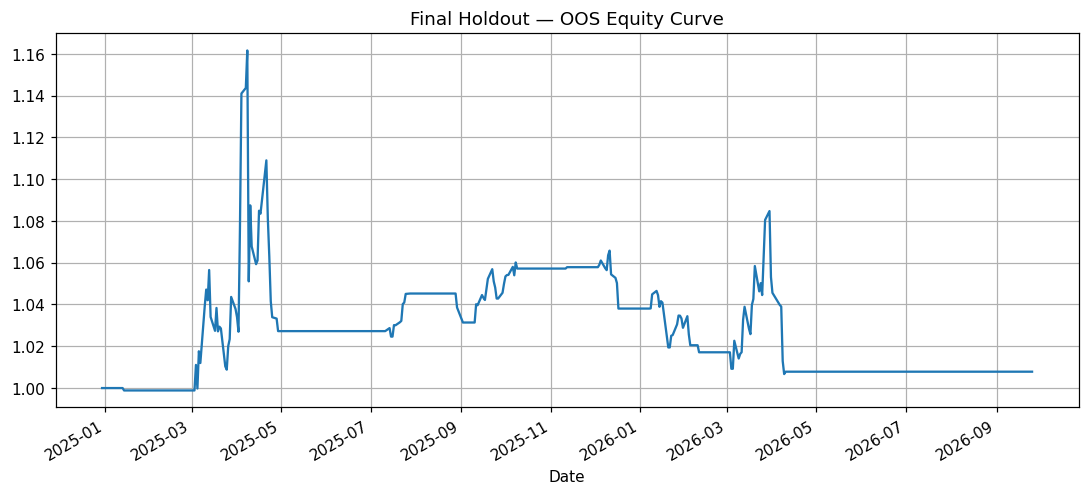

In [17]:
# =========================
# 13) HOLDOUT OOS
# =========================
split = int(len(close)*0.80)
oos_index = close.index[split:]

# Use the best parameters found from the earlier 70% training sample.
best_mom = int(opt.iloc[0]["mom_n"])
best_vol = int(opt.iloc[0]["vol_n"])

full_r = backtest_params(
    close["SPX"],
    features["Growth_Score"],
    best_mom,
    best_vol
)

holdout = full_r.reindex(oos_index).dropna()
display(pd.Series(performance_metrics(holdout), name="Final Holdout OOS"))

((1+holdout).cumprod()).plot(figsize=(12,5), title="Final Holdout — OOS Equity Curve")
plt.show()


## 14. Monte Carlo / bootstrap

The bootstrap keeps the empirical distribution of daily strategy returns while randomizing their order. It estimates the range of possible terminal outcomes under that resampling assumption.


Bootstrap terminal equity percentiles:
5%:  0.75x
50%: 1.01x
95%: 1.32x


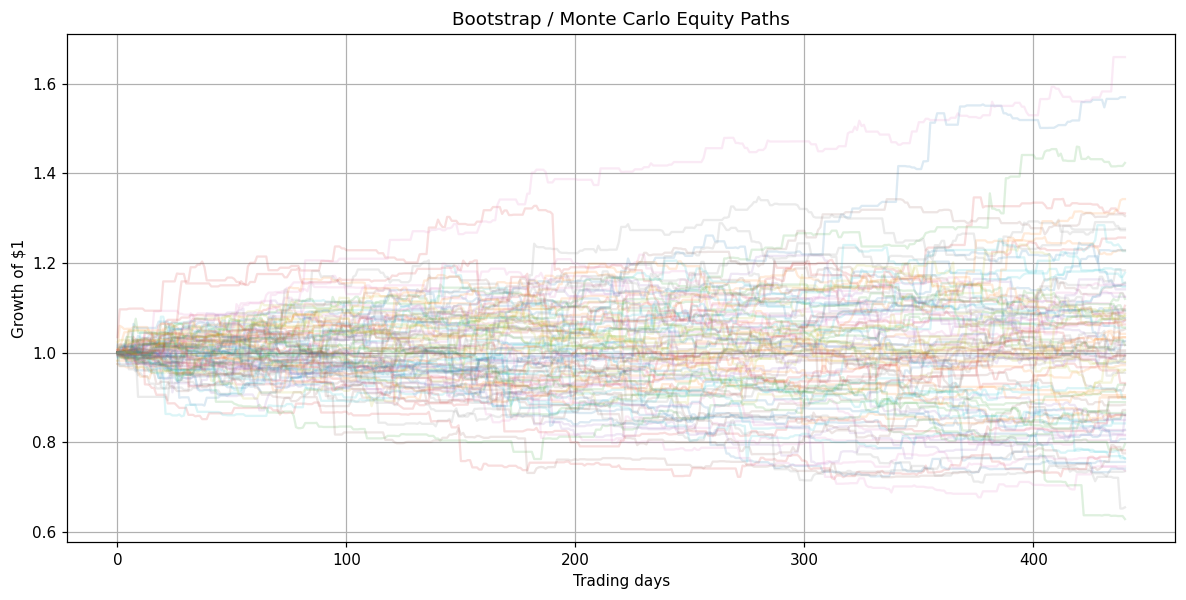

In [18]:
# =========================
# 14) MONTE CARLO / BOOTSTRAP
# =========================
def bootstrap_equity(r, n_sims=1000, seed=42):
    rng = np.random.default_rng(seed)
    r = np.asarray(pd.Series(r).dropna())
    n = len(r)
    samples = rng.choice(r, size=(n_sims, n), replace=True)
    paths = np.cumprod(1 + samples, axis=1)
    return paths

paths = bootstrap_equity(holdout, n_sims=2000)

terminal = paths[:, -1]
p5, p50, p95 = np.percentile(terminal, [5,50,95])

print(f"Bootstrap terminal equity percentiles:")
print(f"5%:  {p5:.2f}x")
print(f"50%: {p50:.2f}x")
print(f"95%: {p95:.2f}x")

fig, ax = plt.subplots(figsize=(13,6))
for i in range(100):
    ax.plot(paths[i], alpha=0.15)
ax.set_title("Bootstrap / Monte Carlo Equity Paths")
ax.set_xlabel("Trading days")
ax.set_ylabel("Growth of $1")
plt.show()


## 15. Optional news engine

This module uses Google News RSS feeds, so no API key is required for a basic prototype. It collects recent headlines and applies VADER sentiment.

For institutional research, replace RSS with a licensed news feed/API and store publication timestamps, source IDs, revisions and event classifications.


In [19]:
# =========================
# 15) NEWS INGESTION
# =========================
analyzer = SentimentIntensityAnalyzer()

NEWS_QUERIES = [
    "S&P 500 Nasdaq futures Federal Reserve inflation",
    "US CPI PCE NFP Federal Reserve Treasury yields",
    "gold oil commodities dollar index",
    "technology stocks earnings semiconductor Nasdaq"
]

def fetch_google_news(query, n=30):
    url = "https://news.google.com/rss/search?q=" + query.replace(" ", "+") + "&hl=en-US&gl=US&ceid=US:en"
    feed = feedparser.parse(url)
    rows = []
    for e in feed.entries[:n]:
        text_all = (e.get("title","") + " " + e.get("summary","")).strip()
        score = analyzer.polarity_scores(text_all)
        rows.append({
            "query": query,
            "title": e.get("title",""),
            "published": e.get("published",""),
            "link": e.get("link",""),
            "sentiment": score["compound"]
        })
    return pd.DataFrame(rows)

news_frames = []
for q in NEWS_QUERIES:
    try:
        news_frames.append(fetch_google_news(q))
    except Exception as e:
        print("News error:", q, e)

news = pd.concat(news_frames, ignore_index=True) if news_frames else pd.DataFrame()
news = news.drop_duplicates("title") if len(news) else news

if len(news):
    news["sentiment_bucket"] = pd.cut(
        news["sentiment"],
        bins=[-1,-0.05,0.05,1],
        labels=["Negative","Neutral","Positive"]
    )
    display(news.sort_values("sentiment", ascending=False).head(20))
else:
    print("No news returned. Check Colab internet/RSS access.")


,query,title,published,link,sentiment,sentiment_bucket
71,gold oil commodities dollar index,Commodity Corner: Oil prices ease on hopes of ...,"Wed, 27 May 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMi7wFBV...,0.9413,Positive
92,technology stocks earnings semiconductor Nasdaq,US stock market could ride earnings strength t...,"Wed, 05 Aug 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiwwFBV...,0.8953,Positive
100,technology stocks earnings semiconductor Nasdaq,Higher bar for corporate profit growth poses c...,"Thu, 09 Jul 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiuAFBV...,0.8910,Positive
64,gold oil commodities dollar index,"Gold, Silver or Copper: Which Commodity Looks ...","Tue, 23 Jun 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMicEFVX...,0.8732,Positive
76,gold oil commodities dollar index,"Commodity Corner: Oil falls, gold gains as mid...","Thu, 04 Jun 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMi9gFBV...,0.8658,Positive
6,S&P 500 Nasdaq futures Federal Reserve inflation,Seahawks QB Sam Darnold ‘Ready To Go’; S Julia...,"Fri, 25 Sep 2026 21:17:42 GMT",https://news.google.com/rss/articles/CBMikwFBV...,0.8555,Positive
33,US CPI PCE NFP Federal Reserve Treasury yields,"How to Trade EUR/USD in 2026: Best Hours, Spre...","Thu, 02 Jul 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiX0FVX...,0.8555,Positive
53,gold oil commodities dollar index,US Market Support and Resistance Update on Sep...,"Thu, 03 Sep 2026 13:44:16 GMT",https://news.google.com/rss/articles/CBMipwFBV...,0.8402,Positive
102,technology stocks earnings semiconductor Nasdaq,SK Hynix surges 12% after Micron earnings; blo...,"Wed, 24 Jun 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiqgFBV...,0.8316,Positive
32,US CPI PCE NFP Federal Reserve Treasury yields,US Dollar Forecast 2026 (H2 Outlook): Will the...,"Sun, 19 Jul 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiYEFVX...,0.7987,Positive


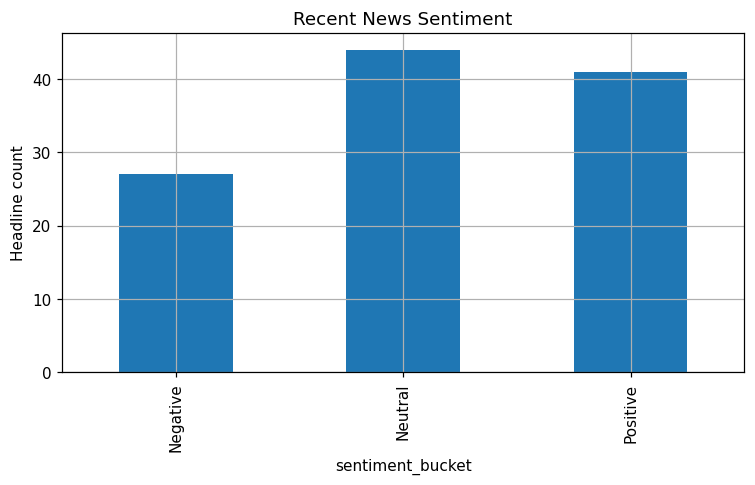

Mean sentiment: 0.06


In [20]:
# =========================
# 16) NEWS SENTIMENT DASHBOARD
# =========================
if len(news):
    counts = news["sentiment_bucket"].value_counts()
    counts.reindex(["Negative","Neutral","Positive"]).plot(
        kind="bar", figsize=(8,4), title="Recent News Sentiment"
    )
    plt.ylabel("Headline count")
    plt.show()

    print("Mean sentiment:", round(news["sentiment"].mean(), 3))


## 17. Event-study style news shock analysis

The next block provides a simple event-study interface. You can enter a date for an important headline/event and measure SPX returns around that date.

For a serious event study, use exact publication timestamps and a high-frequency price series so the event window is aligned correctly.


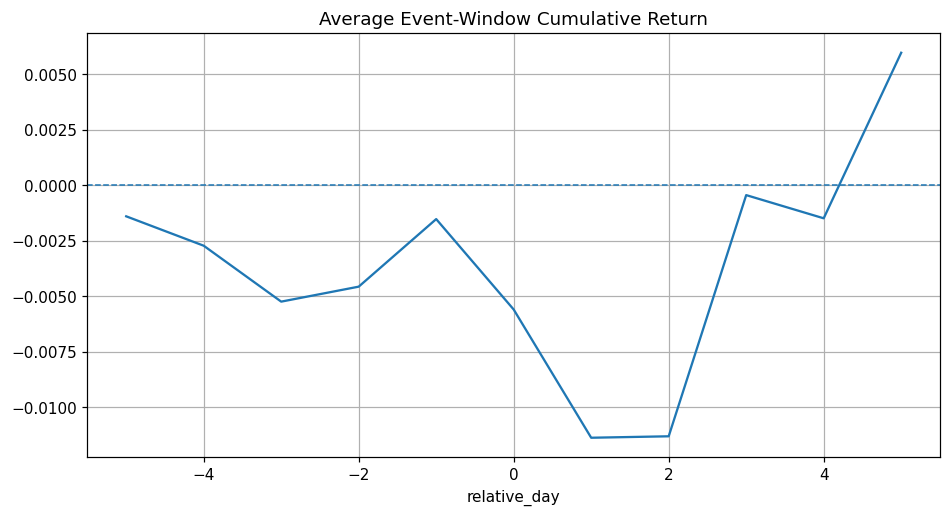

In [21]:
# =========================
# 17) EVENT STUDY
# =========================
def event_study(price, event_dates, pre=5, post=5):
    r = price.pct_change()
    rows = []
    for d in pd.to_datetime(event_dates):
        if d not in r.index:
            idx = r.index.get_indexer([d], method="nearest")[0]
        else:
            idx = r.index.get_loc(d)
        lo, hi = max(0, idx-pre), min(len(r), idx+post+1)
        window = r.iloc[lo:hi].reset_index(drop=True)
        for k, val in enumerate(window):
            rows.append({"event_date": d, "relative_day": k-pre, "return": val})
    return pd.DataFrame(rows)

# Example: replace with actual CPI/FOMC/NFP dates from your event database.
example_events = [close.index[-20], close.index[-10]]
event_df = event_study(close["SPX"], example_events)

if len(event_df):
    avg_event = event_df.groupby("relative_day")["return"].mean()
    avg_cum = (1+avg_event).cumprod()-1
    avg_cum.plot(figsize=(10,5), title="Average Event-Window Cumulative Return")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.show()


## 18. Research report

Run this cell after the notebook has executed to print a compact Bloomberg-style research summary.


In [22]:
# =========================
# 18) FINAL RESEARCH SUMMARY
# =========================
def pct(x):
    return f"{x*100:.2f}%" if pd.notna(x) else "N/A"

print("="*70)
print("NEXUS-QRM — QUANT RESEARCH SUMMARY")
print("="*70)
print("Sample:", close.index.min().date(), "->", close.index.max().date())
print()
print("MARKET")
print("SPX 20D momentum:", pct(features["SPX_Momentum_20D"].iloc[-1]))
print("SPX 20D ann. vol:", pct(features["SPX_Vol_20D"].iloc[-1]))
print("VIX:", round(features["VIX"].iloc[-1],2))
print("Sector breadth:", pct(features["Sector_Breadth"].iloc[-1]))
print("Regime:", features["Regime"].iloc[-1])
print()
print("STRATEGY")
for k,v in performance_metrics(strategy_ret).items():
    if isinstance(v, (float,np.floating)):
        print(f"{k:20s}: {pct(v) if 'Return' in k or 'CAGR' in k or 'Vol' in k or 'Drawdown' in k else round(v,3)}")
    else:
        print(f"{k:20s}: {v}")
print()
print("FINAL HOLDOUT OOS")
for k,v in performance_metrics(holdout).items():
    if isinstance(v, (float,np.floating)):
        print(f"{k:20s}: {pct(v) if 'Return' in k or 'CAGR' in k or 'Vol' in k or 'Drawdown' in k else round(v,3)}")
    else:
        print(f"{k:20s}: {v}")
print("="*70)


NEXUS-QRM — QUANT RESEARCH SUMMARY
Sample: 2018-01-02 -> 2026-09-25

MARKET
SPX 20D momentum: 0.41%
SPX 20D ann. vol: 10.77%
VIX: 14.87
Sector breadth: 36.36%
Regime: Contraction/Risk-Off

STRATEGY
Total Return        : -15.60%
CAGR                : -2.03%
Annualized Vol      : 16.40%
Sharpe              : -0.043
Sortino             : -0.042
Max Drawdown        : -44.20%
Calmar              : -0.046
Avg Daily Turnover  : 0.131
Observations        : 2084

FINAL HOLDOUT OOS
Total Return        : 0.78%
CAGR                : 0.45%
Annualized Vol      : 12.58%
Sharpe              : 0.099
Sortino             : 0.061
Max Drawdown        : -13.34%
Calmar              : 0.034
Avg Daily Turnover  : 0.131
Observations        : 441


## 19. Suggested next upgrade

For a production-grade version, add:
- FOMC/CPI/NFP/PCE/ISM event database
- exact event timestamps and surprise vs consensus
- futures symbols and contract rolls
- slippage/commission model by instrument
- volatility targeting
- position sizing / risk parity
- regime-conditioned alpha models
- NLP news embeddings and entity extraction
- walk-forward parameter stability plots
- purged / embargoed time-series validation
- factor attribution
- portfolio-level VaR / CVaR
- live signal logging

**Important:** do not use a backtest result as evidence that a strategy will make money live. Validate data quality, execution assumptions and robustness before risking capital.
